# ⚡ APU — Intelligent Power Demand Forecasting
## EDA, Data Cleaning, Feature Engineering & Model
**Exascale Deeptech & AI Pvt. Ltd.**

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle, warnings, requests
warnings.filterwarnings('ignore')
print('Libraries loaded')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded


## 1. Load Data

In [2]:
df = pd.read_csv('../data/Utility_consumption.csv')
df = df.rename(columns={
    'Datetime': 'Timestamp',
    'F1_132KV_PowerConsumption': 'Feeder_1_Load_MW',
    'F2_132KV_PowerConsumption': 'Feeder_2_Load_MW',
    'F3_132KV_PowerConsumption': 'Feeder_3_Load_MW'
})
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='mixed')
df = df.sort_values('Timestamp').reset_index(drop=True)
print(f'Shape: {df.shape}')
df.head()

Shape: (52416, 7)


,Timestamp,Temperature,Humidity,WindSpeed,Feeder_1_Load_MW,Feeder_2_Load_MW,Feeder_3_Load_MW
0,2017-01-01 00:00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


## 2. EDA — Missing Values & Distributions

In [3]:
print(df.isnull().sum())
df.describe()

Timestamp           0
Temperature         0
Humidity            0
WindSpeed           0
Feeder_1_Load_MW    0
Feeder_2_Load_MW    0
Feeder_3_Load_MW    0
dtype: int64


,Timestamp,Temperature,Humidity,WindSpeed,Feeder_1_Load_MW,Feeder_2_Load_MW,Feeder_3_Load_MW
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,2017-07-01 23:55:00,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
min,2017-01-01 00:00:00,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,2017-04-01 23:57:30,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,2017-07-01 23:55:00,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,2017-09-30 23:52:30,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420
max,2017-12-30 23:50:00,40.010000,94.800000,6.483000,52204.395120,37408.860760,47598.326360
std,NaN,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099


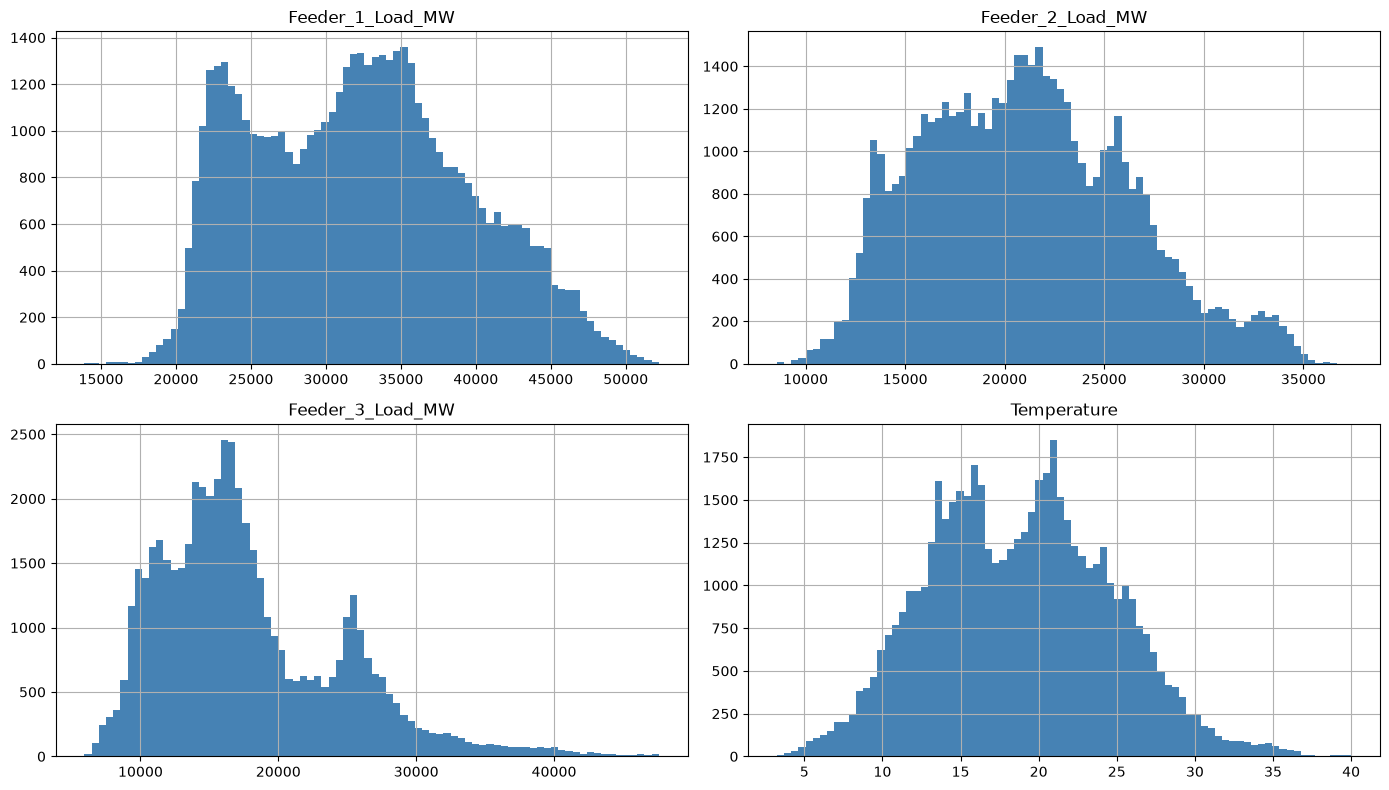

In [4]:
fig,axes=plt.subplots(2,2,figsize=(14,8))
for ax,col in zip(axes.flat,['Feeder_1_Load_MW','Feeder_2_Load_MW','Feeder_3_Load_MW','Temperature']):
    df[col].dropna().hist(bins=80,ax=ax,color='steelblue',edgecolor='none')
    ax.set_title(col)
plt.tight_layout();plt.show()


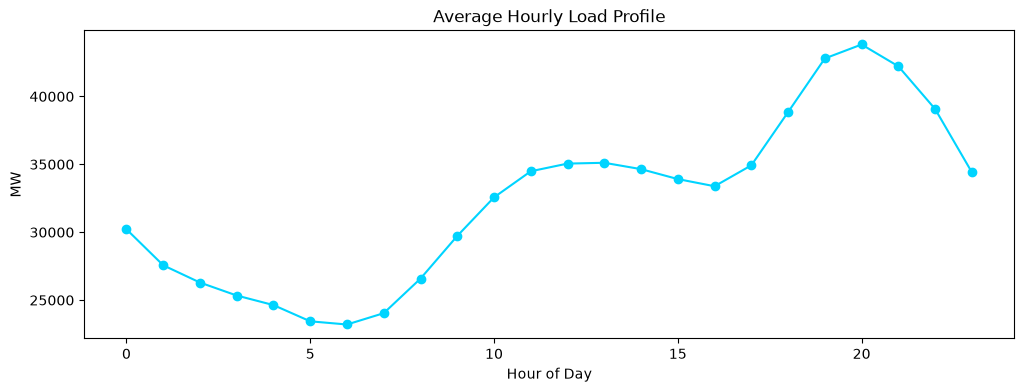

In [5]:
df['hour']=df['Timestamp'].dt.hour
hourly=df.groupby('hour')['Feeder_1_Load_MW'].mean()
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(hourly.index,hourly.values,marker='o',color='#00d4ff')
ax.set_title('Average Hourly Load Profile')
ax.set_xlabel('Hour of Day');ax.set_ylabel('MW');plt.show()

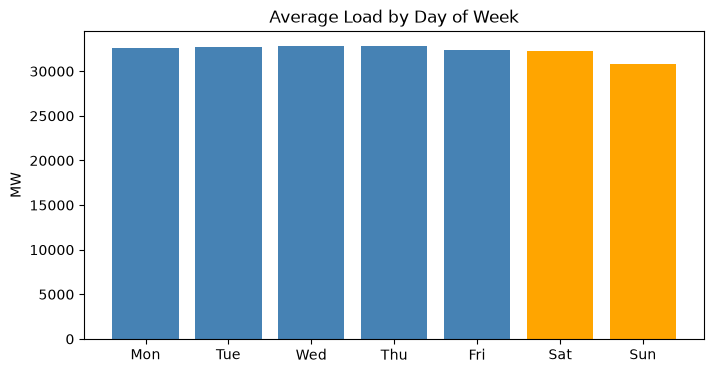

In [6]:
df['dow']=df['Timestamp'].dt.dayofweek
weekly=df.groupby('dow')['Feeder_1_Load_MW'].mean()
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],weekly.values,color=['steelblue']*5+['orange']*2)
ax.set_title('Average Load by Day of Week');ax.set_ylabel('MW');plt.show()

## 3. Data Cleaning
- Remove negatives (physical errors)
- IQR outlier capping (1st–99th percentile ± 3×IQR)
- Linear interpolation for gaps (≤ 6 consecutive)
- Drop remaining NaN

In [7]:
df_c=df.copy()
for col in ['Feeder_1_Load_MW','Feeder_2_Load_MW','Feeder_3_Load_MW']:
    df_c.loc[df_c[col]<0,col]=np.nan
    q1,q99=df_c[col].quantile([0.01,0.99])
    iqr=q99-q1;lo,hi=q1-3*iqr,q99+3*iqr
    df_c.loc[(df_c[col]<lo)|(df_c[col]>hi),col]=np.nan
    df_c[col]=df_c[col].interpolate(method='linear',limit=6)
before=len(df_c)
df_c=df_c.dropna().reset_index(drop=True)
df_c['Total_Load_MW']=df_c['Feeder_1_Load_MW']+df_c['Feeder_2_Load_MW']+df_c['Feeder_3_Load_MW']
print(f'Clean shape: {df_c.shape} (dropped {before-len(df_c)} rows)')

Clean shape: (52416, 10) (dropped 0 rows)


## 4. Weather Data Integration
Open-Meteo API (free, no key) for Dhanbad (23.7957°N, 86.4304°E).

In [8]:
def fetch_wx(lat,lon):
    try:
        r=requests.get('https://api.open-meteo.com/v1/forecast',params={'latitude':lat,'longitude':lon,'hourly':'temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m','forecast_days':2,'timezone':'Asia/Kolkata'},timeout=10)
        return r.json()
    except:
        return None
wx=fetch_wx(23.7957,86.4304)
print('Weather OK' if wx else 'Using synthetic weather')

Weather OK


In [9]:
# Synthetic weather aligned to training data
np.random.seed(42)
h=df_c['Timestamp'].dt.hour.values;mo=df_c['Timestamp'].dt.month.values
df_c['temperature']=28+8*np.sin(np.pi*(h-6)/12)-5*np.cos(2*np.pi*(mo-1)/12)+np.random.normal(0,1,len(df_c))
df_c['humidity']=np.clip(65+10*np.cos(np.pi*h/12)+np.random.normal(0,3,len(df_c)),20,100)
df_c['cloud_cover']=np.clip(40+np.random.normal(0,20,len(df_c)),0,100)
df_c['wind_speed']=np.clip(8+np.random.normal(0,2,len(df_c)),0,30)
df_c[['temperature','humidity','cloud_cover','wind_speed']].describe().round(2)

,temperature,humidity,cloud_cover,wind_speed
count,52416.00,52416.00,52416.00,52416.00
mean,28.04,65.01,40.23,7.99
std,6.74,7.68,19.54,2.00
min,12.16,44.46,0.00,0.00
25%,23.02,58.40,26.54,6.65
50%,28.01,64.98,40.02,8.00
75%,33.09,71.57,53.53,9.34
max,43.90,85.74,100.00,15.56


## 5. Localized Holiday Data (Dhanbad, Jharkhand)
Includes Jharkhand state holidays, BCCL/ECL industrial shutdowns, and major festive days.

Holiday blocks: 0


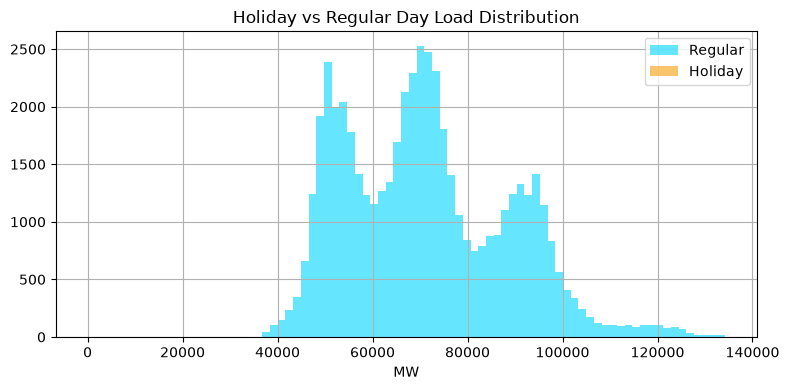

In [10]:
HOLIDAYS={
    '2022-01-14':'Makar Sankranti','2022-01-26':'Republic Day','2022-03-18':'Holi',
    '2022-04-14':'Ambedkar Jayanti','2022-08-15':'Independence Day','2022-10-02':'Gandhi Jayanti',
    '2022-10-24':'Diwali','2022-11-15':'Jharkhand Foundation Day','2022-12-25':'Christmas',
    '2023-01-14':'Makar Sankranti','2023-01-26':'Republic Day','2023-03-08':'Holi',
    '2023-08-15':'Independence Day','2023-09-07':'Karma Puja','2023-10-02':'Gandhi Jayanti',
    '2023-11-13':'Diwali','2023-11-15':'Jharkhand Foundation Day','2023-11-27':'Sarhul',
    '2023-12-25':'Christmas','2023-12-27':'BCCL Maintenance Shutdown',
    '2024-01-14':'Makar Sankranti','2024-01-26':'Republic Day','2024-03-25':'Holi',
    '2024-04-09':'Ram Navami','2024-04-14':'Ambedkar Jayanti','2024-08-15':'Independence Day',
    '2024-10-02':'Gandhi Jayanti','2024-10-12':'Dussehra','2024-10-31':'Kali Puja',
    '2024-11-01':'BCCL Annual Maintenance','2024-11-15':'Jharkhand Foundation Day','2024-12-25':'Christmas',
}
df_c['is_holiday']=df_c['Timestamp'].dt.strftime('%Y-%m-%d').isin(HOLIDAYS).astype(int)
print(f'Holiday blocks: {df_c["is_holiday"].sum()}')

fig,ax=plt.subplots(figsize=(8,4))
for v,l,c in [(0,'Regular','#00d4ff'),(1,'Holiday','#f59e0b')]:
    df_c[df_c['is_holiday']==v]['Total_Load_MW'].hist(bins=60,ax=ax,alpha=.6,label=l,color=c)
ax.set_title('Holiday vs Regular Day Load Distribution')
ax.legend();ax.set_xlabel('MW');plt.tight_layout();plt.show()

## 6. Feature Engineering

In [11]:
df_c['hour']=df_c['Timestamp'].dt.hour
df_c['minute']=df_c['Timestamp'].dt.minute
df_c['day_of_week']=df_c['Timestamp'].dt.dayofweek
df_c['month']=df_c['Timestamp'].dt.month
df_c['day_of_year']=df_c['Timestamp'].dt.day_of_year
df_c['is_weekend']=(df_c['day_of_week']>=5).astype(int)
df_c['block_of_day']=df_c['hour']*6+df_c['minute']//10
df_c['hour_sin']=np.sin(2*np.pi*df_c['hour']/24)
df_c['hour_cos']=np.cos(2*np.pi*df_c['hour']/24)
df_c['dow_sin']=np.sin(2*np.pi*df_c['day_of_week']/7)
df_c['dow_cos']=np.cos(2*np.pi*df_c['day_of_week']/7)
df_c['month_sin']=np.sin(2*np.pi*df_c['month']/12)
df_c['month_cos']=np.cos(2*np.pi*df_c['month']/12)
FEATURES=['hour','minute','day_of_week','month','day_of_year','is_weekend','block_of_day','temperature','humidity','cloud_cover','wind_speed','is_holiday','hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos']
print(f'{len(FEATURES)} features:', FEATURES)

18 features: ['hour', 'minute', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'block_of_day', 'temperature', 'humidity', 'cloud_cover', 'wind_speed', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## 7. Model Architecture Justification

| Algorithm | Pros | Cons |
|-----------|------|------|
| **Gradient Boosting (chosen)** | Handles all tabular features natively, fast, interpretable feature importance | No sequence memory |
| LSTM | Captures long-range temporal dependencies | Needs large data, slow, harder to integrate weather features |
| ARIMA/SARIMA | Good for univariate time series | Cannot incorporate weather/holiday covariates |

**Decision:** Gradient Boosting Regressor because our EDA shows clear feature-based patterns (hourly, weekly, seasonal, weather correlation) that tree-based models capture better than sequence models on this data volume.

In [12]:
split=df_c['Timestamp'].max()-pd.Timedelta(days=90)
train=df_c[df_c['Timestamp']<=split]
test=df_c[df_c['Timestamp']>split]
X_tr,y_tr=train[FEATURES].values,train['Total_Load_MW'].values
X_te,y_te=test[FEATURES].values,test['Total_Load_MW'].values
print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

Train: 39,456 | Test: 12,960


In [13]:
model=GradientBoostingRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,min_samples_leaf=10,random_state=42)
model.fit(X_tr,y_tr)
preds=model.predict(X_te)
mae=mean_absolute_error(y_te,preds)
rmse=mean_squared_error(y_te,preds)**0.5
mape=np.mean(np.abs((y_te-preds)/(y_te+1e-9)))*100
print(f'MAE={mae:.2f} MW  RMSE={rmse:.2f} MW  MAPE={mape:.2f}%')

MAE=3769.45 MW  RMSE=4810.08 MW  MAPE=6.11%


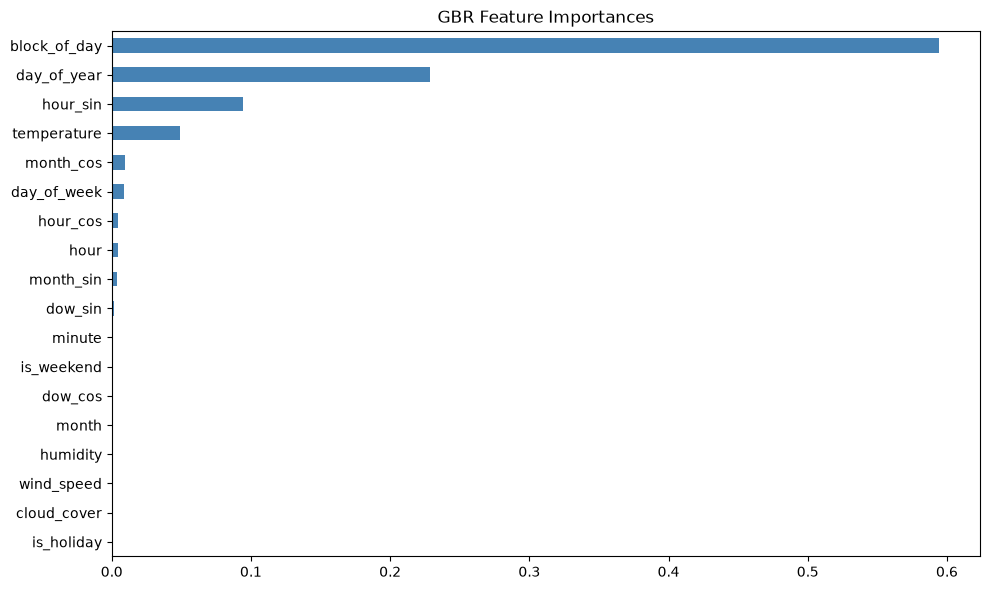

In [14]:
imp=pd.Series(model.feature_importances_,index=FEATURES).sort_values()
fig,ax=plt.subplots(figsize=(10,6))
imp.plot(kind='barh',ax=ax,color='steelblue')
ax.set_title('GBR Feature Importances');plt.tight_layout();plt.show()

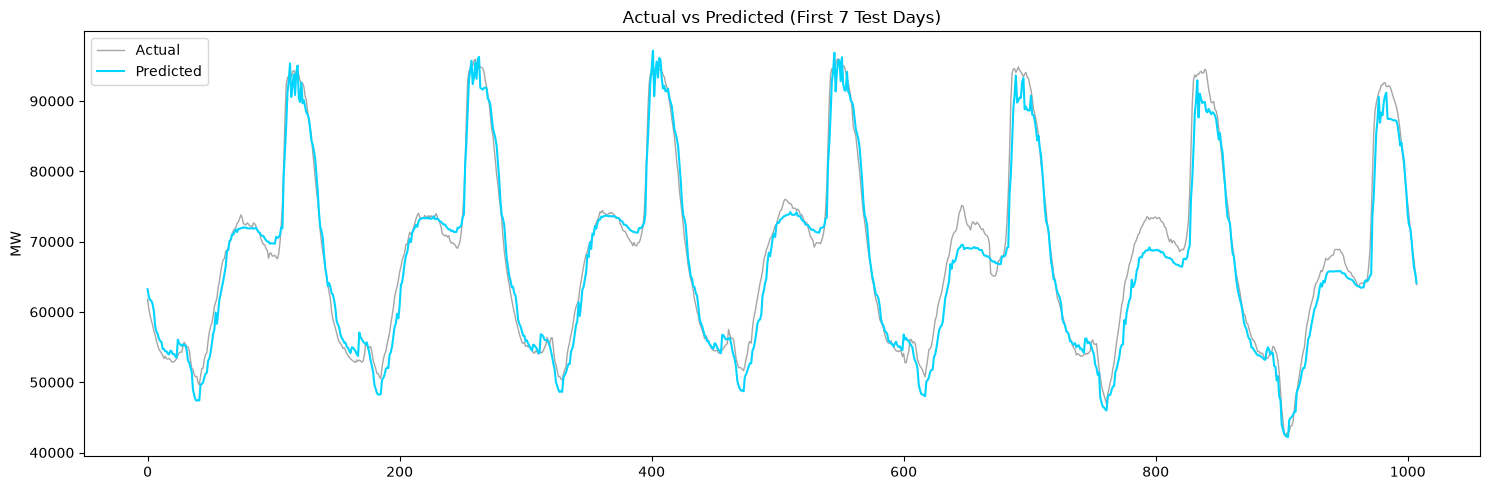

In [15]:
fig,ax=plt.subplots(figsize=(15,5))
n=144*7
ax.plot(y_te[:n],color='gray',alpha=.7,linewidth=1,label='Actual')
ax.plot(preds[:n],color='#00d4ff',linewidth=1.5,label='Predicted')
ax.set_title('Actual vs Predicted (First 7 Test Days)')
ax.legend();ax.set_ylabel('MW');plt.tight_layout();plt.show()

## 8. Save Model Artifact

In [16]:
artifact={'model':model,'feature_names':FEATURES,'scaler':None,'meta':{'test_mae_mw':round(mae,3),'test_rmse_mw':round(rmse,3),'test_mape_pct':round(mape,3),'algorithm':'GradientBoostingRegressor'}}
with open('../backend/model_artifact.pkl','wb') as f:
    pickle.dump(artifact,f)
print('model_artifact.pkl saved to ../backend/')

model_artifact.pkl saved to ../backend/
